In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [33]:
train = pd.read_csv("customer_churn_dataset-training-master.csv")
test = pd.read_csv("customer_churn_dataset-testing-master.csv")

print(train.head())
print(train.info())

   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0  Female    39.0             14.0            5.0   
1         3.0  65.0  Female    49.0              1.0           10.0   
2         4.0  55.0  Female    14.0              4.0            6.0   
3         5.0  58.0    Male    38.0             21.0            7.0   
4         6.0  23.0    Male    32.0             20.0            5.0   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0           18.0          Standard          Annual        932.0   
1            8.0             Basic         Monthly        557.0   
2           18.0             Basic       Quarterly        185.0   
3            7.0          Standard         Monthly        396.0   
4            8.0             Basic         Monthly        617.0   

   Last Interaction  Churn  
0              17.0    1.0  
1               6.0    1.0  
2               3.0    1.0  
3              29.0    1.0  
4              20.0    1.

In [34]:
train = train.dropna()
test = test.dropna()

In [35]:
train = pd.get_dummies(train, columns=['Gender','Subscription Type','Contract Length'])
test = pd.get_dummies(test, columns=['Gender','Subscription Type','Contract Length'])

# align both datasets
train, test = train.align(test, join='left', axis=1, fill_value=0)

In [36]:
train.head()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Female,Gender_Male,Subscription Type_Basic,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Annual,Contract Length_Monthly,Contract Length_Quarterly
0,2.0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,1.0,True,False,False,False,True,True,False,False
1,3.0,65.0,49.0,1.0,10.0,8.0,557.0,6.0,1.0,True,False,True,False,False,False,True,False
2,4.0,55.0,14.0,4.0,6.0,18.0,185.0,3.0,1.0,True,False,True,False,False,False,False,True
3,5.0,58.0,38.0,21.0,7.0,7.0,396.0,29.0,1.0,False,True,False,False,True,False,True,False
4,6.0,23.0,32.0,20.0,5.0,8.0,617.0,20.0,1.0,False,True,True,False,False,False,True,False


In [37]:
X = train.drop(['CustomerID','Churn'], axis=1)
y = train['Churn']

X_test = test.drop(['CustomerID','Churn'], axis=1)
y_test = test['Churn']

In [38]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

In [39]:
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

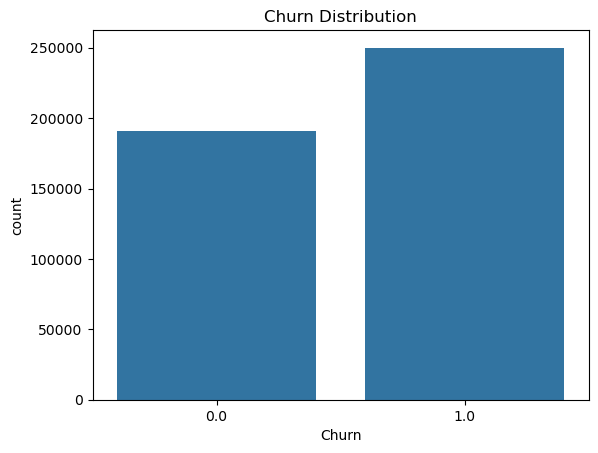

In [40]:
sns.countplot(x='Churn', data=train)
plt.title("Churn Distribution")
plt.show()

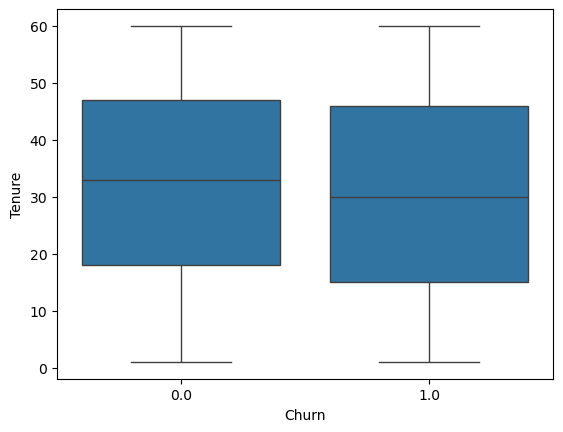

In [41]:
sns.boxplot(x='Churn', y='Tenure', data=train)
plt.show()

In [42]:
class_counts = train['Churn'].value_counts()
class_percentages = train['Churn'].value_counts(normalize=True) * 100

# Combine into a readable table
balance_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_percentages
})

print(balance_df)

        Count  Percentage (%)
Churn                        
1.0    249999        56.71072
0.0    190833        43.28928


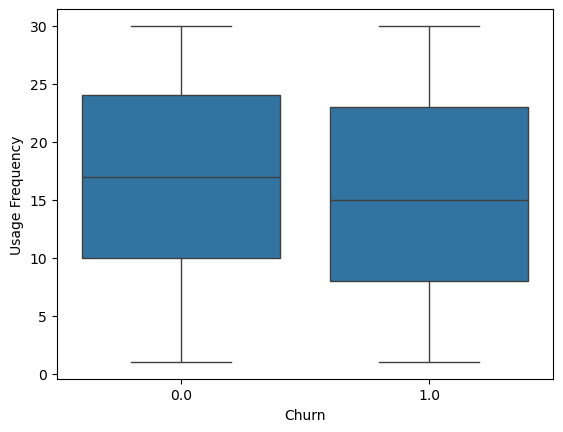

In [43]:
sns.boxplot(x='Churn', y='Usage Frequency', data=train)
plt.show()

### Logistic Regression

In [44]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_val)

In [45]:
print(classification_report(y_val, pred_lr))

              precision    recall  f1-score   support

         0.0       0.86      0.91      0.88     38063
         1.0       0.93      0.89      0.91     50104

    accuracy                           0.90     88167
   macro avg       0.89      0.90      0.90     88167
weighted avg       0.90      0.90      0.90     88167



### Random Forest (Better Performance)

In [56]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_val)

In [55]:
print(classification_report(y_val, pred_rf))

              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99     38063
         1.0       1.00      0.98      0.99     50104

    accuracy                           0.99     88167
   macro avg       0.99      0.99      0.99     88167
weighted avg       0.99      0.99      0.99     88167



#### Test Dataset Performance

In [51]:
test_pred = rf.predict(X_test_scaled)

print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.98      0.08      0.14     33881
           1       0.49      1.00      0.66     30493

    accuracy                           0.51     64374
   macro avg       0.74      0.54      0.40     64374
weighted avg       0.75      0.51      0.39     64374



### Confusion Matrix

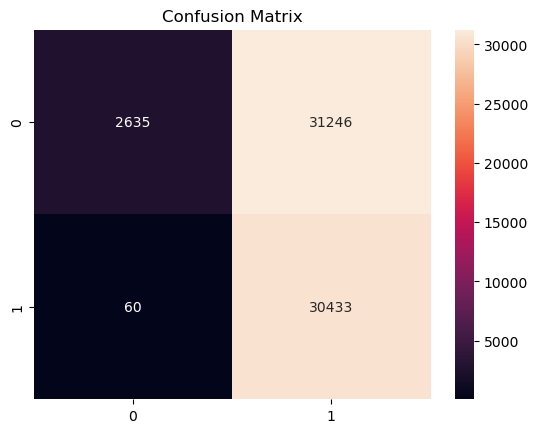

In [57]:
cm = confusion_matrix(y_test, test_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

#### Feature Importance

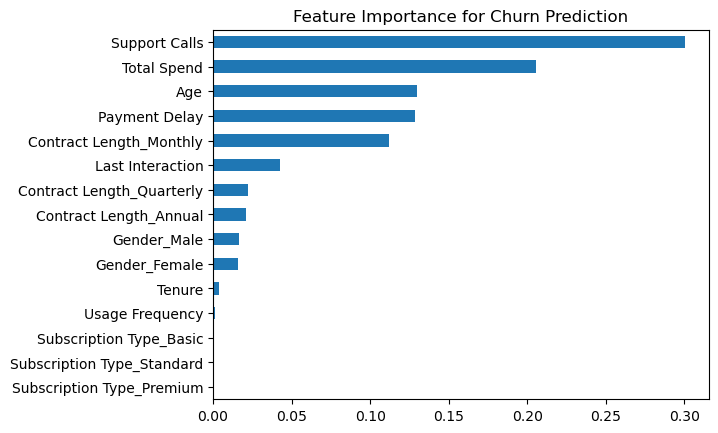

In [53]:
importances = rf.feature_importances_

features = X.columns

feat_imp = pd.Series(importances, index=features)

feat_imp.sort_values().plot(kind='barh')

plt.title("Feature Importance for Churn Prediction")
plt.show()